## Data Loading & Initial Inspection
Loaded the `bodyPerformance.csv` dataset (13,393 records, 12 features). No missing values were found and all columns have appropriate data types.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('bodyPerformance.csv')

# Display the first few rows
print(df.head())

# Check for missing values and data types
print(df.info())

    age gender  height_cm  weight_kg  body fat_%  diastolic  systolic  \
0  27.0      M      172.3      75.24        21.3       80.0     130.0   
1  25.0      M      165.0      55.80        15.7       77.0     126.0   
2  31.0      M      179.6      78.00        20.1       92.0     152.0   
3  32.0      M      174.5      71.10        18.4       76.0     147.0   
4  28.0      M      173.8      67.70        17.1       70.0     127.0   

   gripForce  sit and bend forward_cm  sit-ups counts  broad jump_cm class  
0       54.9                     18.4            60.0          217.0     C  
1       36.4                     16.3            53.0          229.0     A  
2       44.8                     12.0            49.0          181.0     C  
3       41.4                     15.2            53.0          219.0     B  
4       43.5                     27.1            45.0          217.0     B  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 

# **1.Classification**


## Data Preprocessing & Pruning Path Generation
Engineered two new features (BMI, grip-per-weight), encoded the gender column, and applied a stratified 75/25 train-test split. Generated all candidate `ccp_alpha` values to prepare for cost complexity pruning.

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

# 1. Load the dataset
# Ensure the file path matches your environment
df = pd.read_csv('bodyPerformance.csv')

# 2. Feature Engineering: Creating new metrics to improve model understanding
# Calculate Body Mass Index (BMI)
df['BMI'] = df['weight_kg'] / ((df['height_cm'] / 100) ** 2)
# Calculate grip force relative to body weight
df['grip_per_weight'] = df['gripForce'] / df['weight_kg']

# 3. Label Encoding for Categorical Data
# Convert gender (M/F) to numeric (0/1)
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

# 4. Define features (X) and target variable (y)
X = df.drop('class', axis=1)
y = df['class']

# Initial split (will be overwritten by the stratified split below)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Define the base Decision Tree model
dt_clf = DecisionTreeClassifier(random_state=42)

# 5. Final Train-Test Split
# Using stratify=y to ensure consistent class distribution between sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 6. Cost Complexity Pruning: Get possible alpha values
# This path provides candidate alpha values for pruning the tree
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas  # candidate alpha values

# 7. Iterating through Alphas to find the optimal model
results = []

for alpha in ccp_alphas:
    # Train a new tree for each candidate alpha
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train, y_train)

    # Evaluate performance on both training and testing sets
    train_acc = clf.score(X_train, y_train)
    test_acc = clf.score(X_test, y_test)

    # Store results for comparison
    results.append({
        "alpha": alpha,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "node_count": clf.tree_.node_count,
        "depth": clf.tree_.max_depth
    })

# 8. Store results in a DataFrame for analysis
results_df = pd.DataFrame(results)

# Display the first few rows of the results
print(results_df.head())

      alpha  train_accuracy  test_accuracy  node_count  depth
0  0.000000        1.000000       0.649448        3983     28
1  0.000065        0.999900       0.649448        3977     28
2  0.000080        0.999801       0.649149        3973     28
3  0.000083        0.999602       0.649149        3965     28
4  0.000083        0.999602       0.649149        3965     28


## Optimal Alpha Selection — Classification
Identified the alpha that maximizes test accuracy. The plot confirms the sweet spot between overfitting (low alpha) and underfitting (high alpha).

--- Optimal Model Results ---
Best Alpha: 0.000377
Best Test Accuracy: 71.07%
Nodes in Best Tree: 477
Final Tree Depth: 14 levels


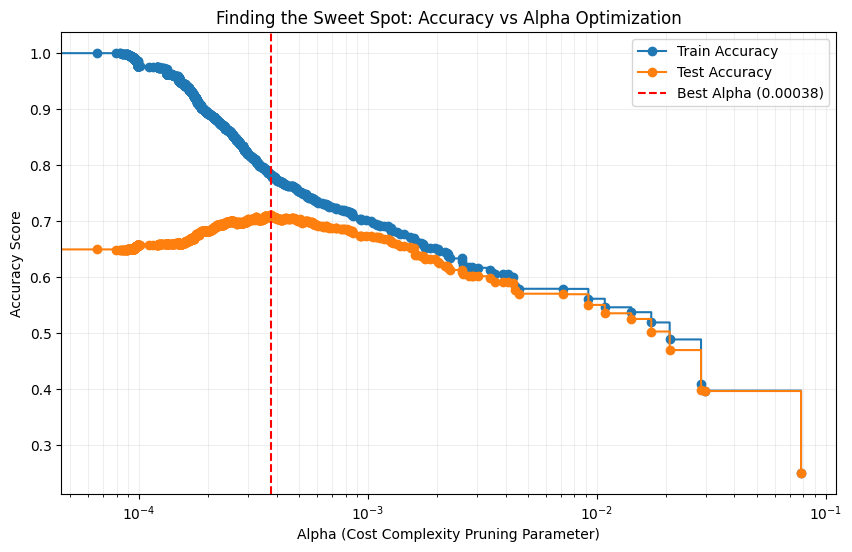

In [62]:
# 1. Finding the optimal alpha that achieved the highest test accuracy
# idxmax() finds the index of the maximum value in the test_accuracy column
best_result = results_df.loc[results_df['test_accuracy'].idxmax()]

# Printing the key metrics for the report
print("--- Optimal Model Results ---")
print(f"Best Alpha: {best_result['alpha']:.6f}")
print(f"Best Test Accuracy: {best_result['test_accuracy'] * 100:.2f}%")
print(f"Nodes in Best Tree: {int(best_result['node_count'])}")
print(f"Final Tree Depth: {int(best_result['depth'])} levels") # New line added as requested

# 2. Visualizing the relationship between Alpha and Accuracy
plt.figure(figsize=(10, 6))

# Plotting Training Accuracy vs Alpha
plt.plot(results_df['alpha'], results_df['train_accuracy'], marker='o',
         label='Train Accuracy', drawstyle="steps-post")

# Plotting Testing Accuracy vs Alpha
plt.plot(results_df['alpha'], results_df['test_accuracy'], marker='o',
         label='Test Accuracy', drawstyle="steps-post")

# Drawing a vertical dashed line at the best alpha point
plt.axvline(x=best_result['alpha'], color='r', linestyle='--',
            label=f'Best Alpha ({best_result["alpha"]:.5f})')

# Adding labels and title in English
plt.xlabel("Alpha (Cost Complexity Pruning Parameter)")
plt.ylabel("Accuracy Score")
plt.title("Finding the Sweet Spot: Accuracy vs Alpha Optimization")
plt.legend()

# Using a Logarithmic scale to visualize small alpha values more clearly
plt.xscale('log')
plt.grid(True, which="both", ls="-", alpha=0.2)

# Display the plot
plt.show()

## Final Classifier Evaluation
Trained the optimized model using the best alpha. The classification report and confusion matrix show the model's accuracy per class, and the feature importance plot highlights the most influential features.


--- Final Model Detailed Classification Report ---
              precision    recall  f1-score   support

           A       0.71      0.85      0.77       837
           B       0.58      0.58      0.58       837
           C       0.67      0.62      0.65       838
           D       0.90      0.78      0.84       837

    accuracy                           0.71      3349
   macro avg       0.72      0.71      0.71      3349
weighted avg       0.72      0.71      0.71      3349



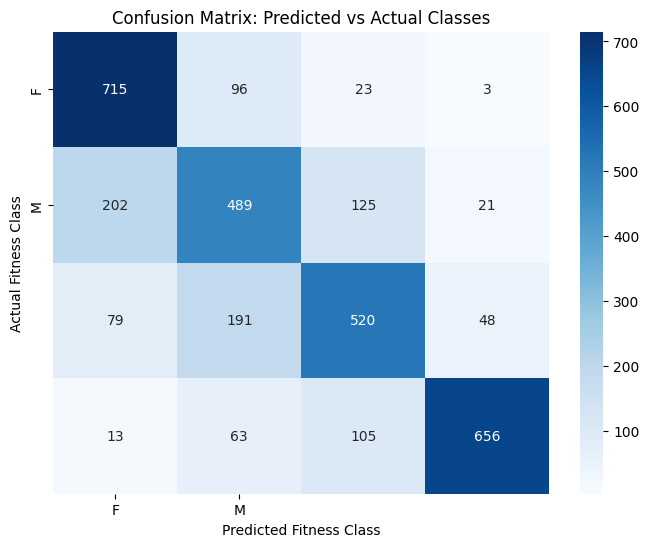

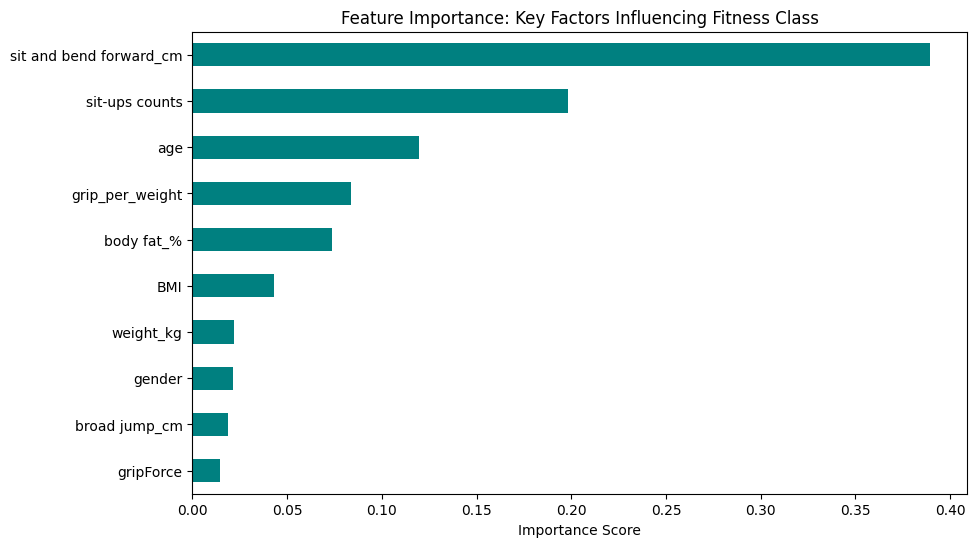

In [63]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Train the final optimized model using the best alpha found
# We use the best_result['alpha'] we just calculated
final_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_result['alpha'])
final_model.fit(X_train, y_train)

# 2. Make predictions on the test set
y_pred = final_model.predict(X_test)

# 3. Generate a Detailed Classification Report
# This shows Precision, Recall, and F1-Score for each class (A, B, C, D)
# We use the original class names from le_class for clarity
print("\n--- Final Model Detailed Classification Report ---")
target_names = [str(c) for c in le.classes_] if 'le' in locals() else None
print(classification_report(y_test, y_pred))

# 4. Visualize the Confusion Matrix
# This helps us see which classes are being confused with each other
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Predicted vs Actual Classes')
plt.ylabel('Actual Fitness Class')
plt.xlabel('Predicted Fitness Class')
plt.show()

# 5. Feature Importance Plot
# This identifies which body measurements (like BMI or gripForce) were most important
plt.figure(figsize=(10, 6))
importances = pd.Series(final_model.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance: Key Factors Influencing Fitness Class')
plt.xlabel('Importance Score')
plt.show()

## Split Ratio Experiments & Cross-Validation — Classification
Tested the model across 80/20, 70/30, and 50/50 splits to assess sensitivity to training size. 5-Fold CV confirmed stable generalization with low variance.

In [64]:
from sklearn.model_selection import cross_val_score, KFold

# 1. Defining the data splits
splits = [0.20, 0.30, 0.50]
split_results = []

print("--- Running Required Experiments ---")

for test_size in splits:
    # Splitting the data based on the current experiment ratio
    X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # Using the best alpha we found earlier to keep the comparison fair
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_result['alpha'])
    model.fit(X_train_exp, y_train_exp)

    # Calculating Accuracy for this specific split
    train_acc = model.score(X_train_exp, y_train_exp)
    test_acc = model.score(X_test_exp, y_test_exp)

    split_results.append({
        "Split Ratio (Test %)": f"{int(test_size*100)}%",
        "Train Acc": f"{train_acc*100:.2f}%",
        "Test Acc": f"{test_acc*100:.2f}%"
    })

# 2. Performing K-Fold Cross Validation (as required by the Handbook)
# We use 5 or 10 folds commonly in machine learning
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(final_model, X, y, cv=kf)

# 3. Displaying Final Comparison Table
results_comparison_df = pd.DataFrame(split_results)
print(results_comparison_df)

print(f"\n--- K-Fold Cross Validation (5 Folds) ---")
print(f"Average CV Accuracy: {cv_scores.mean()*100:.2f}%")
print(f"Standard Deviation: {cv_scores.std()*100:.2f}%")

--- Running Required Experiments ---
  Split Ratio (Test %) Train Acc Test Acc
0                  20%    78.04%   72.15%
1                  30%    79.08%   70.58%
2                  50%    85.96%   67.06%

--- K-Fold Cross Validation (5 Folds) ---
Average CV Accuracy: 70.39%
Standard Deviation: 1.39%


## Decision Tree Visualization — Classification
Rendered the top 3 levels of the optimized tree to illustrate how the model makes split decisions and which features appear at the earliest (most important) nodes.

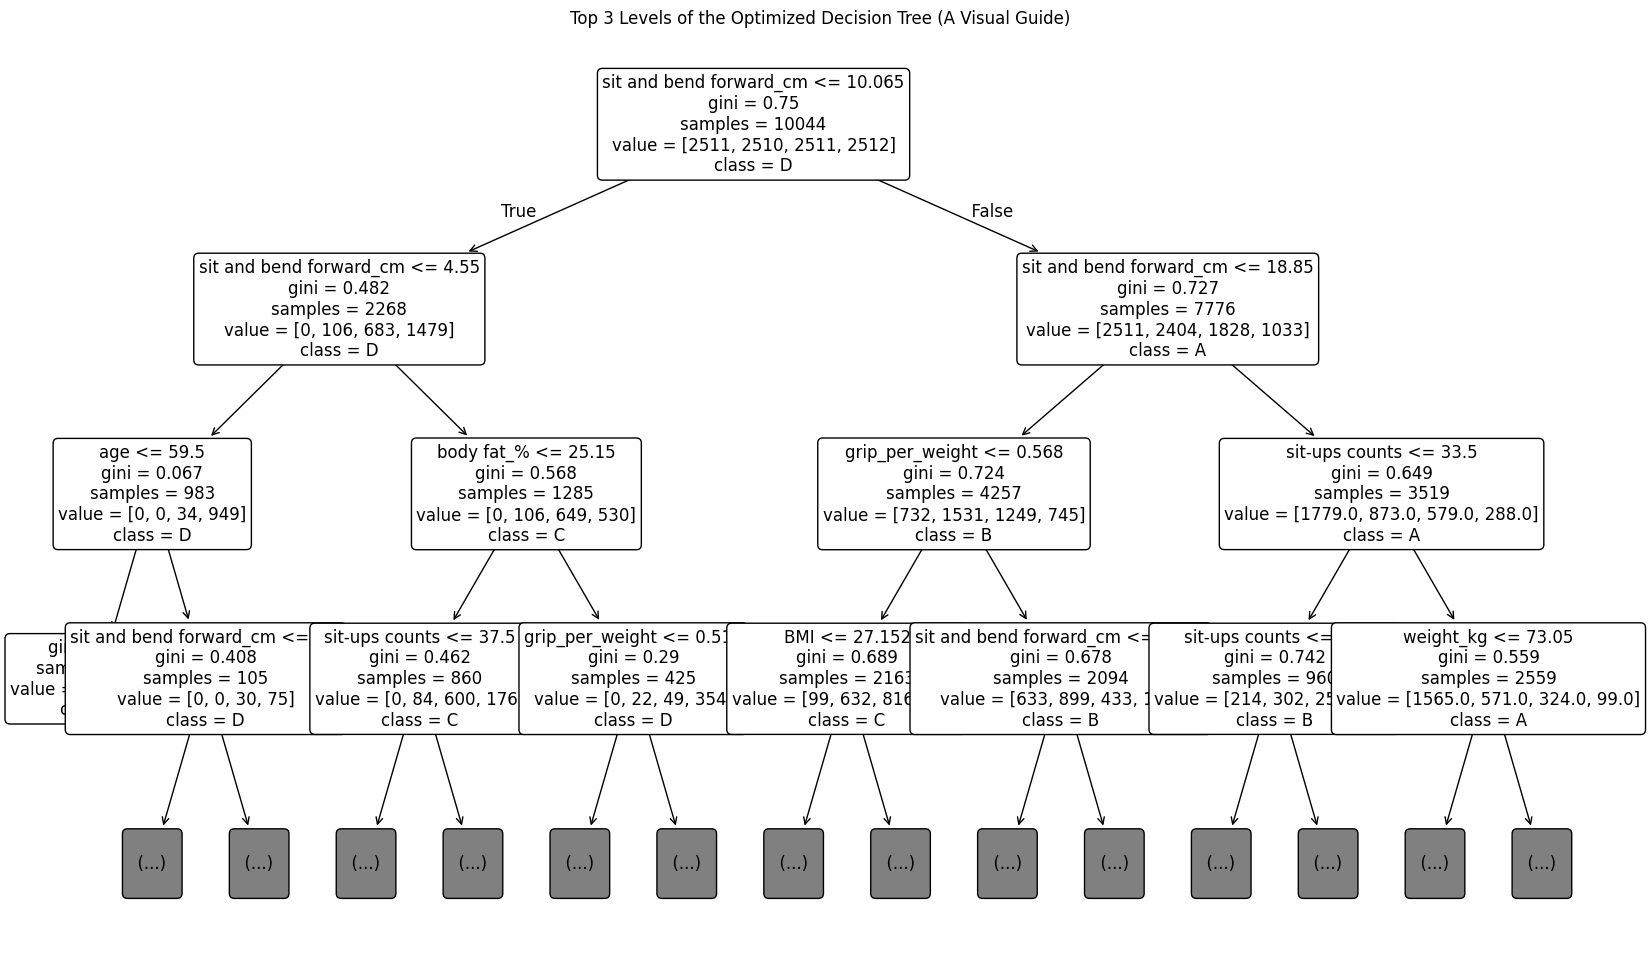

In [65]:
from sklearn.tree import plot_tree

# 1. Defining the class names for the plot to make it readable
# We map the numbers (0, 1, 2, 3) back to original classes (A, B, C, D)
# The previous `le` was for 'gender'. We need class names for the 'class' column.
# Get unique classes from the target variable `y` and sort them.
class_names_list = sorted(y.unique())

# 2. Visualizing the top levels of the Decision Tree
# We limit the depth to 3 levels to keep the plot clean and readable
plt.figure(figsize=(20, 12)) # Creating a large canvas for the plot
plot_tree(final_model,
          max_depth=3, # ONLY plotting the top 3 levels of the 14-level tree
          feature_names=X.columns, # Displaying feature names (like BMI)
          class_names=class_names_list, # Displaying class labels (like A)
          filled=False, # Coloring the nodes based on class majority
          rounded=True, # Rounding the node corners
          fontsize=12) # Setting a readable font size

# Adding a descriptive title for the handbook documentation
plt.title("Top 3 Levels of the Optimized Decision Tree (A Visual Guide)")
plt.show()

## Class Overlap Analysis
Scatter and KDE plots reveal significant overlap between fitness classes, which explains why the model doesn't achieve perfect accuracy — the classes are not linearly separable.

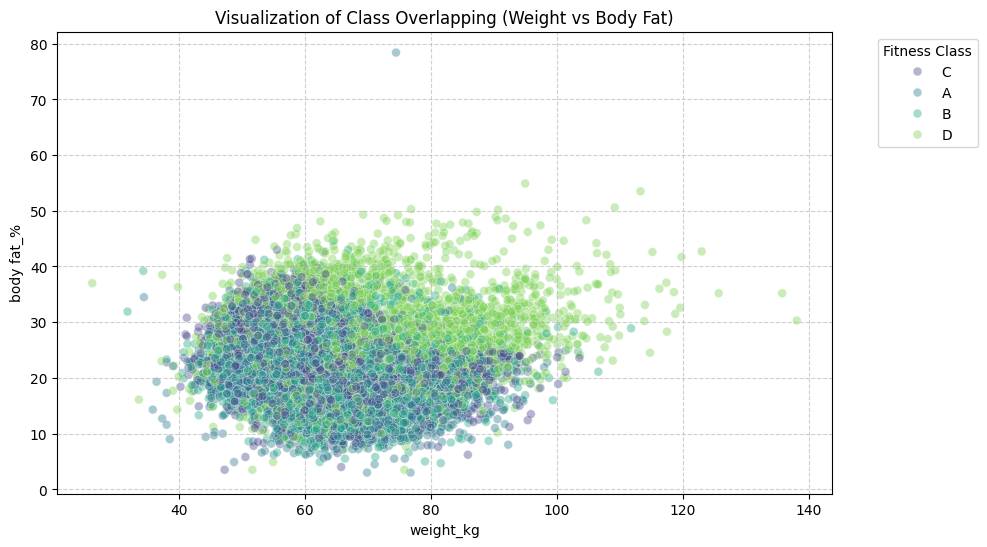

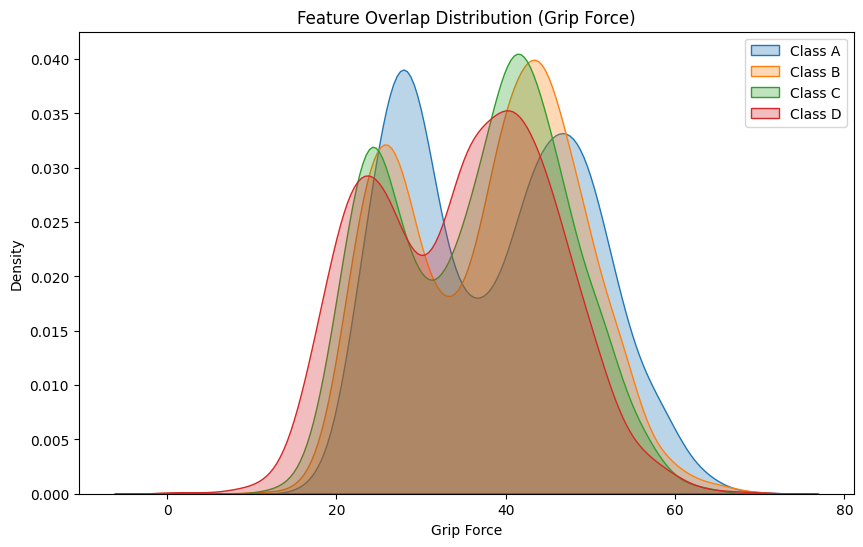

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visualizing Class Overlapping using Scatter Plot (Weight vs Body Fat)
# This plot helps identify how classes are mixed in the feature space
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='weight_kg', y='body fat_%', hue='class',
                palette='viridis', alpha=0.4, s=40)

plt.title('Visualization of Class Overlapping (Weight vs Body Fat)')
plt.legend(title='Fitness Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Analyzing Feature Overlap using Kernel Density Estimate (KDE Plot)
# This shows the distribution of Grip Force across different fitness classes
plt.figure(figsize=(10, 6))
for cls in sorted(df['class'].unique()):
    # The 'class' column already contains string labels, so no inverse_transform is needed.
    # Using 'cls' directly as the class name.
    cls_name = cls
    sns.kdeplot(df[df['class'] == cls]['gripForce'], label=f'Class {cls_name}', fill=True, alpha=0.3)

plt.title('Feature Overlap Distribution (Grip Force)')
plt.xlabel('Grip Force')
plt.ylabel('Density')
plt.legend()
plt.show()

## Underfitting Demonstration — Classification

*   List item
*   List item


Forced underfitting using a high `ccp_alpha`. The drop in accuracy confirms that excessive pruning oversimplifies the model and loses predictive power.

In [67]:
# Demonstrating Underfitting (High Alpha) ---
# By increasing ccp_alpha to a high value (e.g., 0.002), we force the tree
# to become too simple, which leads to "Underfitting".

underfit_model = DecisionTreeClassifier(random_state=42, ccp_alpha=0.002)
underfit_model.fit(X_train, y_train)

# Calculating results for comparison
underfit_test_acc = underfit_model.score(X_test, y_test)
underfit_nodes = underfit_model.tree_.node_count
underfit_depth = underfit_model.tree_.max_depth

print(f"--- Underfitted Model Results ---")
print(f"Underfit Test Accuracy: {underfit_test_acc * 100:.2f}%")
print(f"Node Count: {underfit_nodes}")
print(f"Tree Depth: {underfit_depth} levels")

--- Underfitted Model Results ---
Underfit Test Accuracy: 63.18%
Node Count: 69
Tree Depth: 8 levels


# **2.Regression**


## Regression Setup & Pruning Path Generation
Defined the regression target (`broad_jump_cm`) and sampled 50 alpha values to efficiently search for the optimal pruning level for the `DecisionTreeRegressor`.

In [68]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

# Prepare data for regression task
# Define the target variable for regression
y_reg = df['broad jump_cm']
# Define features for regression, dropping 'class' (classification target) and the new regression target
X_reg = df.drop(['class', 'broad jump_cm'], axis=1)

# Split the data into training and testing sets for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

# 1. Get the cost complexity pruning path to find candidate alpha values
reg_clf_base = DecisionTreeRegressor(random_state=42)
path = reg_clf_base.cost_complexity_pruning_path(X_train_reg, y_train_reg)
ccp_alphas_reg = path.ccp_alphas

# 2. Iterate through 50 sampled alpha values for high efficiency and speed
reg_results = []
alpha_subset = np.linspace(0, ccp_alphas_reg.max(), 50)

for alpha in alpha_subset:
    # Train a new regressor for each sampled alpha
    model = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    model.fit(X_train_reg, y_train_reg)

    # Calculate R-squared scores for both training and testing sets
    train_r2 = model.score(X_train_reg, y_train_reg)
    test_r2 = model.score(X_test_reg, y_test_reg)

    # Store model complexity and performance results
    reg_results.append({
        "alpha": alpha,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "node_count": model.tree_.node_count,
        "depth": model.tree_.max_depth
    })

# 3. Convert results to a DataFrame and identify the optimal model
reg_results_df = pd.DataFrame(reg_results)
best_reg_row = reg_results_df.loc[reg_results_df['test_r2'].idxmax()]

# Display final performance metrics and model structure
print("--- Final Optimized Results ---")
print(f"Best Alpha found: {best_reg_row['alpha']:.6f}")
print(f"Max Test R2 Score: {best_reg_row['test_r2']:.4f}")
print(f"Tree Depth: {best_reg_row['depth']}")
print(f"Node Count: {best_reg_row['node_count']}")

--- Final Optimized Results ---
Best Alpha found: 16.212985
Max Test R2 Score: 0.6770
Tree Depth: 3.0
Node Count: 13.0


## Optimal Alpha Selection — Regression
Identified the alpha that maximizes test R². The R² vs. Alpha plot confirms the trade-off between model complexity and generalization.

--- Optimal Regression Model Results ---
Best Alpha: 16.212985
Best Test R2 Score: 0.6770
Nodes in Best Tree: 13
Final Tree Depth: 3 levels


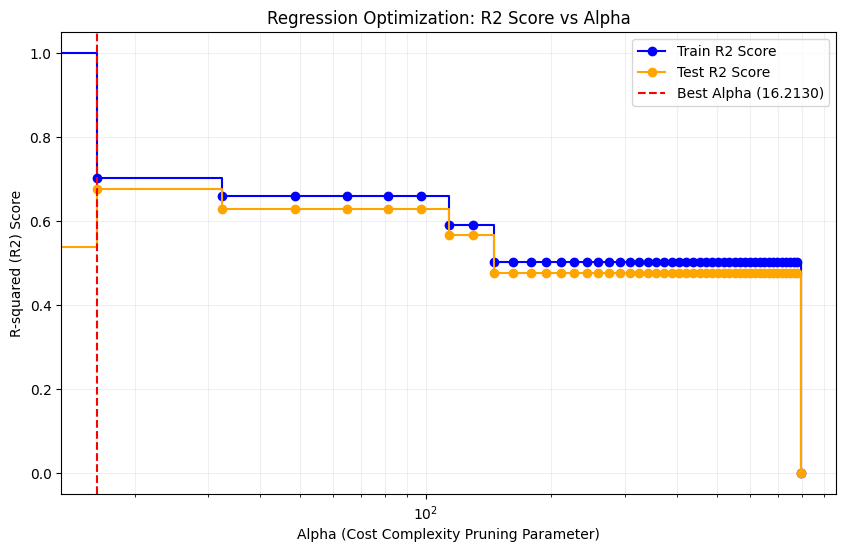

In [69]:
# 1. Finding the optimal alpha that achieved the highest test R2 score
# idxmax() finds the index of the maximum value in the test_r2 column
best_reg_result = reg_results_df.loc[reg_results_df['test_r2'].idxmax()]

# Printing the key metrics for the regression report
print("--- Optimal Regression Model Results ---")
print(f"Best Alpha: {best_reg_result['alpha']:.6f}")
print(f"Best Test R2 Score: {best_reg_result['test_r2']:.4f}")
print(f"Nodes in Best Tree: {int(best_reg_result['node_count'])}")
print(f"Final Tree Depth: {int(best_reg_result['depth'])} levels")

# 2. Visualizing the relationship between Alpha and R2 Score
plt.figure(figsize=(10, 6))

# Plotting Training R2 vs Alpha
plt.plot(reg_results_df['alpha'], reg_results_df['train_r2'], marker='o',
         label='Train R2 Score', drawstyle="steps-post", color='blue')

# Plotting Testing R2 vs Alpha
plt.plot(reg_results_df['alpha'], reg_results_df['test_r2'], marker='o',
         label='Test R2 Score', drawstyle="steps-post", color='orange')

# Drawing a vertical dashed line at the best alpha point
plt.axvline(x=best_reg_result['alpha'], color='red', linestyle='--',
            label=f'Best Alpha ({best_reg_result["alpha"]:.4f})')

# Adding labels and title in English for the Regression task
plt.xlabel("Alpha (Cost Complexity Pruning Parameter)")
plt.ylabel("R-squared (R2) Score")
plt.title("Regression Optimization: R2 Score vs Alpha")
plt.legend()

# Using a Logarithmic scale if alphas are small, or keep it linear based on your results
# Since your best alpha was ~16, we can keep it linear or use log if you have many small values
plt.xscale('log')
plt.grid(True, which="both", ls="-", alpha=0.2)

# Display the plot
plt.show()

## Final Regressor Evaluation
Trained the optimized regression model. RMSE and R² metrics quantify prediction error, and the Actual vs. Predicted plot shows how closely the model tracks real values.


--- Final Regression Model Performance ---
Mean Squared Error (MSE): 520.87
Root Mean Squared Error (RMSE): 22.82 cm
R-squared Score (R2): 0.6770


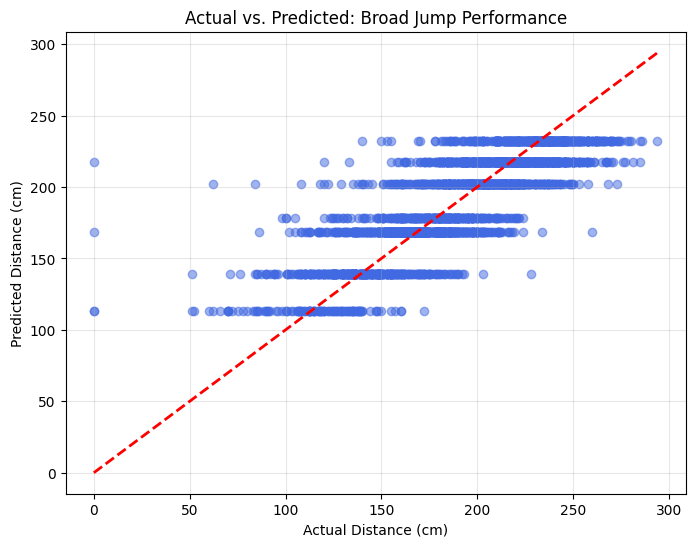

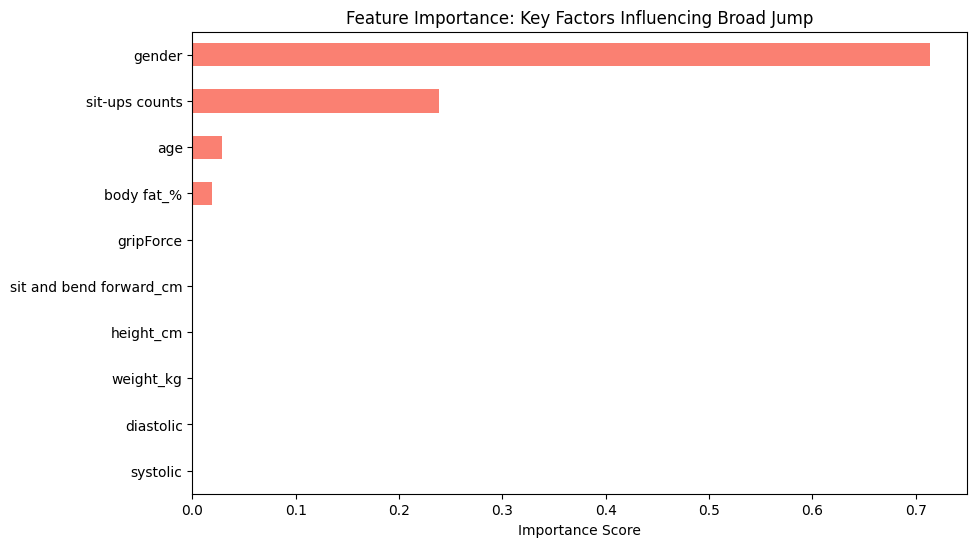

In [70]:
from sklearn.metrics import mean_squared_error, r2_score

# 1. Train the final optimized Regression model using the best alpha found
# We use the best_reg_result['alpha'] from our optimization step
final_reg_model = DecisionTreeRegressor(random_state=42, ccp_alpha=best_reg_result['alpha'])
final_reg_model.fit(X_train_reg, y_train_reg)

# 2. Make predictions on the test set
y_pred_reg = final_reg_model.predict(X_test_reg)

# 3. Generate Regression Metrics Report
# Instead of accuracy, we use R2 and MSE for continuous values
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("\n--- Final Regression Model Performance ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} cm")
print(f"R-squared Score (R2): {r2:.4f}")

# 4. Visualize Actual vs. Predicted Values
# This replaces the Confusion Matrix for regression tasks
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5, color='royalblue')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted: Broad Jump Performance')
plt.ylabel('Predicted Distance (cm)')
plt.xlabel('Actual Distance (cm)')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Feature Importance Plot (Regression)
# To see which factors influence the Broad Jump distance the most
plt.figure(figsize=(10, 6))
importances_reg = pd.Series(final_reg_model.feature_importances_, index=X_reg.columns)
importances_reg.nlargest(10).sort_values().plot(kind='barh', color='salmon')
plt.title('Feature Importance: Key Factors Influencing Broad Jump')
plt.xlabel('Importance Score')
plt.show()

## Split Ratio Experiments & Cross-Validation — Regression
Repeated the split experiments for regression (without stratify). 5-Fold CV using R² scoring confirmed consistent performance across different data partitions.

In [71]:
from sklearn.model_selection import cross_val_score, KFold

# 1. Defining the data splits (Regression Version)
splits = [0.20, 0.30, 0.50]
split_results_reg = []

print("--- Running Regression Split Experiments ---")

for test_size in splits:
    # Splitting the data - Note: 'stratify' is REMOVED for regression
    X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
        X_reg, y_reg, test_size=test_size, random_state=42
    )

    # Using the best alpha found for the Regression model
    model_reg = DecisionTreeRegressor(random_state=42, ccp_alpha=best_reg_row['alpha'])
    model_reg.fit(X_train_exp, y_train_exp)

    # Calculating R2 Score for this specific split
    train_r2 = model_reg.score(X_train_exp, y_train_exp)
    test_r2 = model_reg.score(X_test_exp, y_test_exp)

    split_results_reg.append({
        "Split Ratio (Test %)": f"{int(test_size*100)}%",
        "Train R2": f"{train_r2:.4f}",
        "Test R2": f"{test_r2:.4f}"
    })

# 2. Performing K-Fold Cross Validation for Regression
# We use 'r2' as the scoring metric instead of accuracy
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_reg = cross_val_score(final_reg_model, X_reg, y_reg, cv=kf, scoring='r2')

# 3. Displaying Final Comparison Table
results_comparison_df = pd.DataFrame(split_results_reg)
print(results_comparison_df)

print(f"\n--- K-Fold Cross Validation (5 Folds - R2 Score) ---")
print(f"Average CV R2: {cv_scores_reg.mean():.4f}")
print(f"Standard Deviation: {cv_scores_reg.std():.4f}")

--- Running Regression Split Experiments ---
  Split Ratio (Test %) Train R2 Test R2
0                  20%   0.7017  0.6768
1                  30%   0.6921  0.6699
2                  50%   0.7069  0.6852

--- K-Fold Cross Validation (5 Folds - R2 Score) ---
Average CV R2: 0.6947
Standard Deviation: 0.0149


## Regression Tree Visualization
Rendered the full optimized regression tree. Leaf nodes display the mean predicted jump distance, showing how the model partitions the feature space into value ranges.

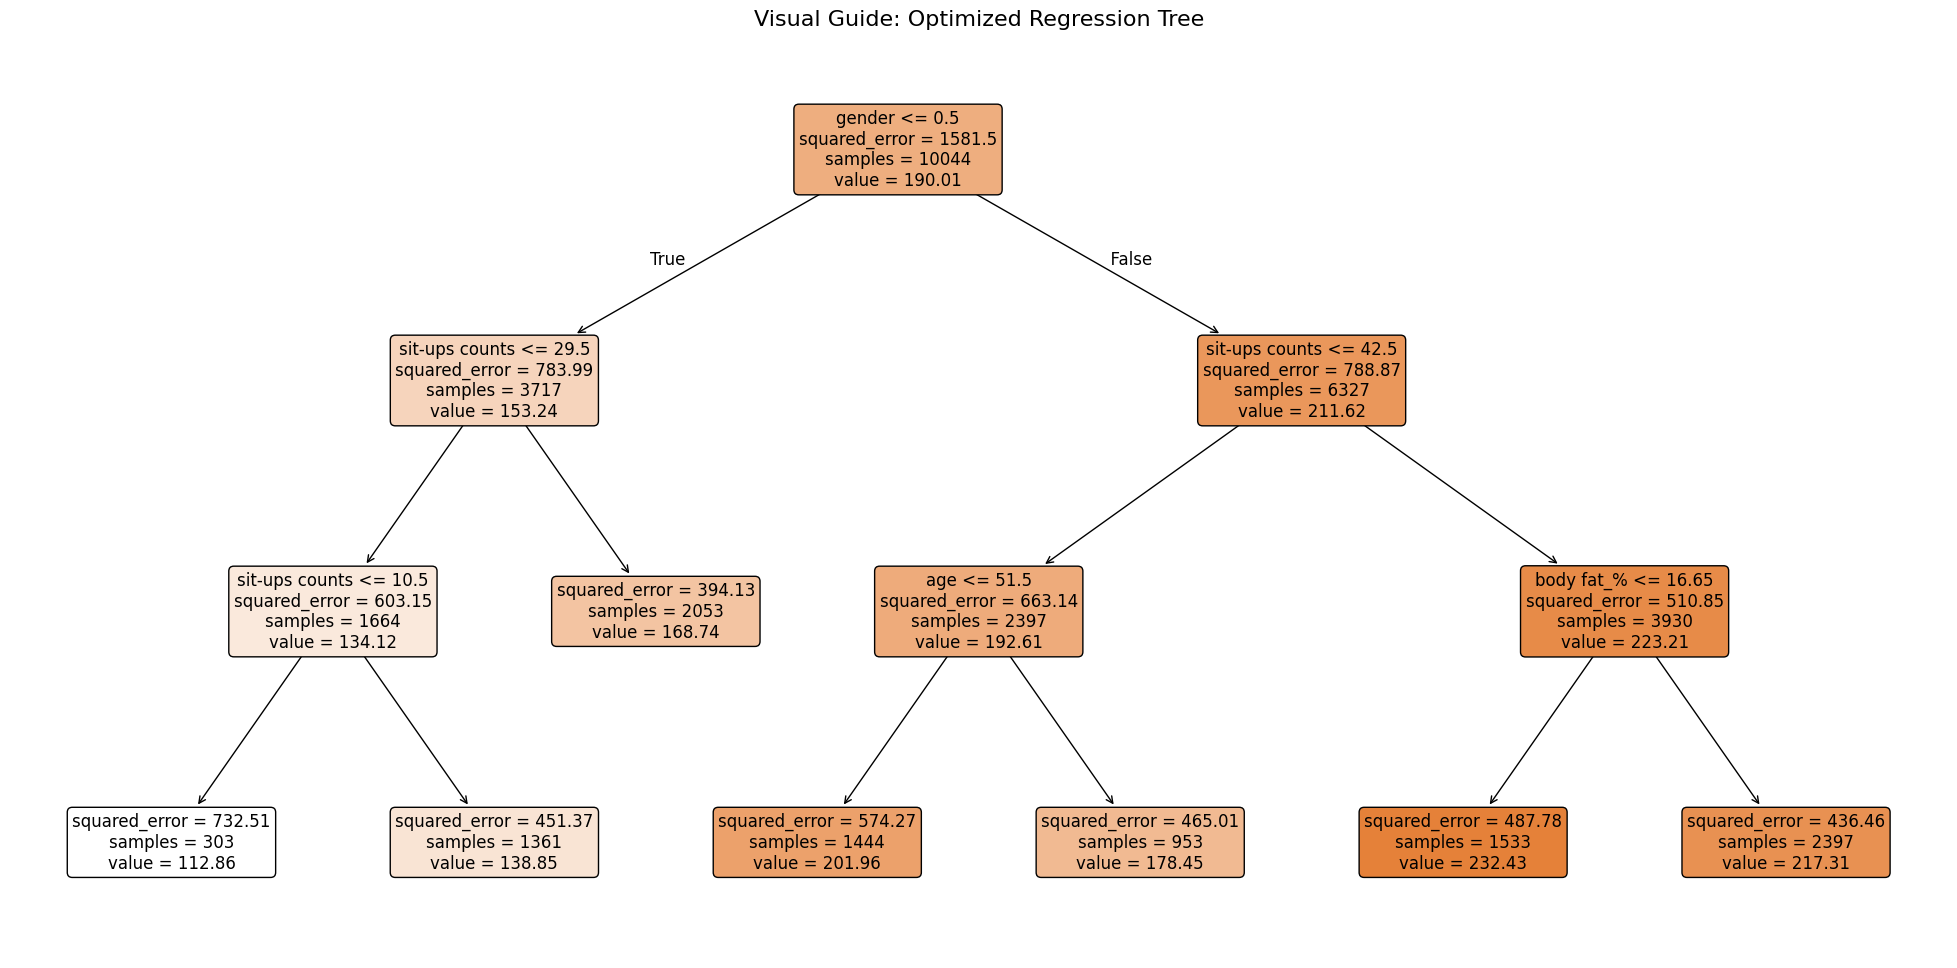

In [72]:
from sklearn.tree import plot_tree

# 1. Visualizing the Final Optimized Regression Tree
# Note: In Regression, we don't have 'class_names'.
# The tree predicts a continuous 'value' (the mean jump distance for that node).

# Creating a large canvas to ensure the tree is clear for the handbook
plt.figure(figsize=(25, 12))

# 2. Plotting the Regression Tree
plot_tree(final_reg_model,
          feature_names=X_reg.columns, # Using regression feature names
          filled=True,             # Coloring nodes based on the predicted value intensity
          rounded=True,            # Rounding corners for a professional look
          precision=2,             # Showing 2 decimal places for the predicted values
          fontsize=12)

# Adding a professional English title for your documentation
plt.title("Visual Guide: Optimized Regression Tree", fontsize=16)
plt.show()

## Residual Analysis
The Actual vs. Predicted plot and residuals distribution confirm that prediction errors are approximately centered around zero with no major systematic bias.

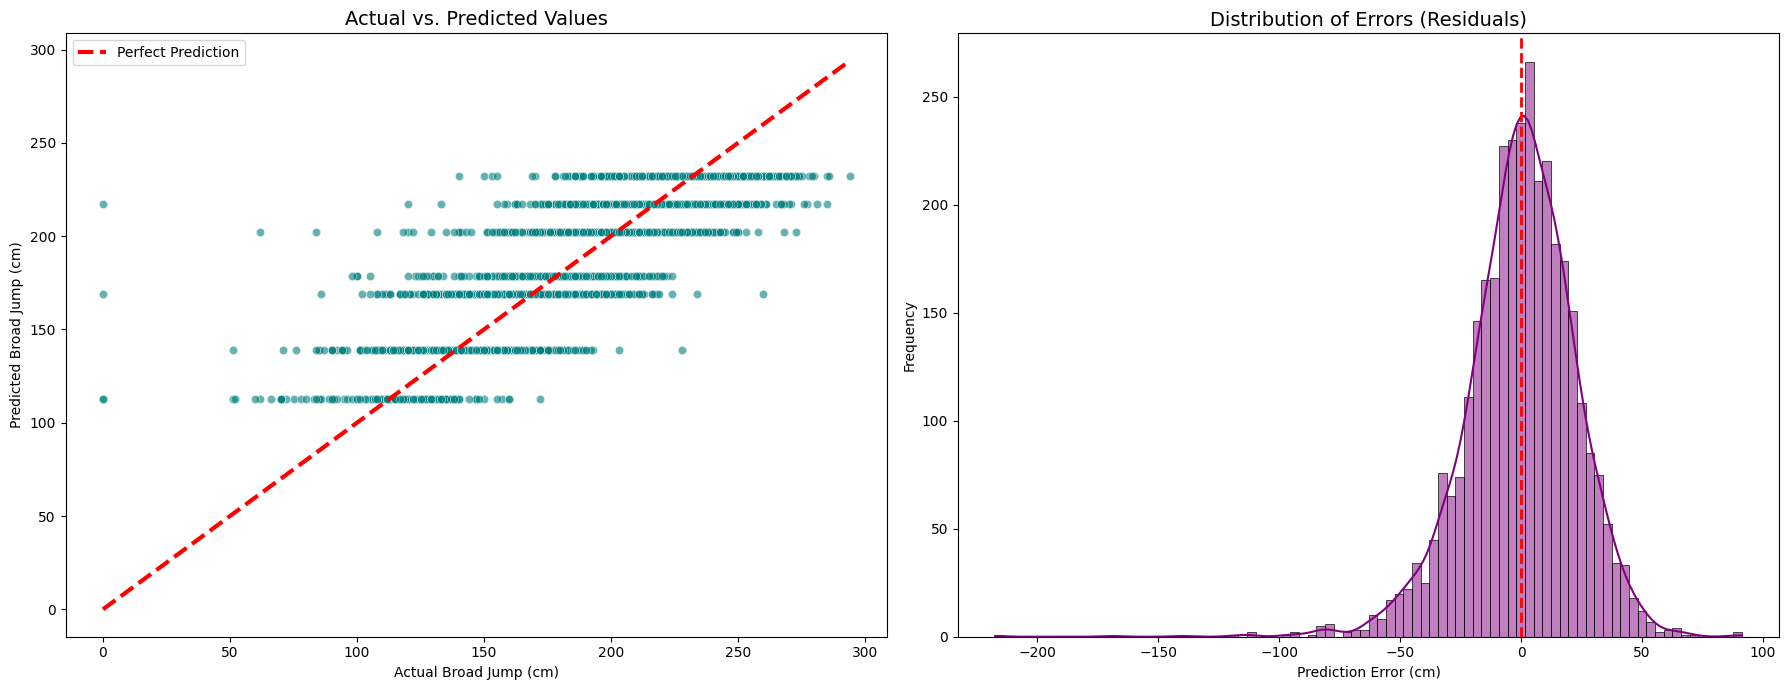

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculating Residuals (The difference between Actual and Predicted)
residuals = y_test_reg - y_pred_reg

# 2. Creating the Professional Regression Diagnostic Plot
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot A: Actual vs Predicted (The 'Identity' Line) ---
sns.scatterplot(x=y_test_reg, y=y_pred_reg, alpha=0.6, ax=ax[0], color='teal')
ax[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()],
           'r--', lw=3, label='Perfect Prediction')
ax[0].set_title('Actual vs. Predicted Values', fontsize=14)
ax[0].set_xlabel('Actual Broad Jump (cm)')
ax[0].set_ylabel('Predicted Broad Jump (cm)')
ax[0].legend()

# --- Plot B: Residuals Distribution (The 'Error' Check) ---
sns.histplot(residuals, kde=True, ax=ax[1], color='purple')
ax[1].axvline(x=0, color='red', linestyle='--', lw=2)
ax[1].set_title('Distribution of Errors (Residuals)', fontsize=14)
ax[1].set_xlabel('Prediction Error (cm)')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Experiment 4: Underfitting Demonstration — Regression
Used `ccp_alpha=500` to force a near-stump tree (1 level). The low R² confirms the model is too simple to capture any meaningful patterns.

In [74]:
# --- Experiment 4: Demonstrating Underfitting (High Alpha) ---
# For Regression, a high alpha (like 500 or 1000 depending on your scale)
# forces the tree to underfit.

high_alpha = 500 # Adjust this based on your previous alpha search
underfit_reg_model = DecisionTreeRegressor(random_state=42, ccp_alpha=high_alpha)
underfit_reg_model.fit(X_train_reg, y_train_reg)

# Calculating results
underfit_test_r2 = underfit_reg_model.score(X_test_reg, y_test_reg)
underfit_nodes = underfit_reg_model.tree_.node_count
underfit_depth = underfit_reg_model.tree_.max_depth

print(f"--- Underfitted Regression Model Results ---")
print(f"Underfit Test R2 Score: {underfit_test_r2:.4f}")
print(f"Node Count: {underfit_nodes}")
print(f"Tree Depth: {underfit_depth} levels")

--- Underfitted Regression Model Results ---
Underfit Test R2 Score: 0.4766
Node Count: 3
Tree Depth: 1 levels


## Experiment 4: Overfitting Demonstration — Regression
Disabled pruning entirely (`ccp_alpha=0`). Train R² reached 1.0 while test R² dropped significantly, confirming classic overfitting behavior.

In [75]:
# --- Experiment 4: Attempting to Maximize Accuracy (Zero Pruning) ---
# Here we let the tree grow to its maximum possible depth (No Alpha)
overcomplex_model = DecisionTreeRegressor(random_state=42, ccp_alpha=0.0)
overcomplex_model.fit(X_train_reg, y_train_reg)

# Training vs Testing Performance
train_r2_max = overcomplex_model.score(X_train_reg, y_train_reg)
test_r2_max = overcomplex_model.score(X_test_reg, y_test_reg)

print(f"--- Over-Complex Model (Zero Pruning) ---")
print(f"Training R2 Score: {train_r2_max:.4f} (Almost Perfect)")
print(f"Testing R2 Score: {test_r2_max:.4f} (Lower than Optimized)")
print(f"Max Depth: {overcomplex_model.tree_.max_depth} levels")

--- Over-Complex Model (Zero Pruning) ---
Training R2 Score: 1.0000 (Almost Perfect)
Testing R2 Score: 0.5389 (Lower than Optimized)
Max Depth: 38 levels
